In [1]:
%%time
%pip install pandas matplotlib scikit-learn pmdarima portalocker>=2.0.0 plotly dash
%pip install torch==2.3.0+cpu torchdata==0.9.0+cpu torchtext==0.18.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 MB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 83.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.0 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0+cpu
    Uninstalling torch-2.10.0+cpu:
      Successfully uninstalled torch-2.10.0+cpu
  Attempting uninstall: torchdata
    Found existing installation: torchdata 0.11.0
    Uninstalling torchdata-0.11.0:
      Successfully uninstalled torchdata-0.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cpu requires torch==2.10.0, but you have torch 2.3.0+cpu which is incompatible.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.9.0+cpu which is incompatible.
t

In [2]:
%%capture
import warnings
from tqdm import tqdm

warnings.simplefilter('ignore')
import time
from collections import OrderedDict

import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import string
import time

from sklearn.manifold import TSNE

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

**Helper functions**

In [3]:
def preprocess_string(s):
    # Remove all non-word characters (everything except numbers and letters)
    s = re.sub(r"[^\w\s]", '', s)
    # Replace all runs of whitespaces with no space
    s = re.sub(r"\s+", '', s)
    # replace digits with no space
    s = re.sub(r"\d", '', s)

    return s

**Language modeling**

In [4]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

**Natural Language Toolkit (NLTK)**

**Tokenization**

In [5]:
from nltk.tokenize import word_tokenize
def preprocess(words):
   # print(words)
    tokens=word_tokenize(words)
    tokens=[preprocess_string(w) for w in tokens]
    return [w.lower()  for w in tokens if len(w)!=0 and (w not in string.punctuation) ]

tokens=preprocess(song)
print(tokens)

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules', 'and', 'so', 'do', 'i', 'a', 'full', 'commitments', 'what', 'im', 'thinking', 'of', 'you', 'wouldnt', 'get', 'this', 'from', 'any', 'other', 'guy', 'i', 'just', 'wan', 'na', 'tell', 'you', 'how', 'im', 'feeling', 'got', 'ta', 'make', 'you', 'understand', 'never', 'gon', 'na', 'give', 'you', 'up', 'never', 'gon', 'na', 'let', 'you', 'down', 'never', 'gon', 'na', 'run', 'around', 'and', 'desert', 'you', 'never', 'gon', 'na', 'make', 'you', 'cry', 'never', 'gon', 'na', 'say', 'goodbye', 'never', 'gon', 'na', 'tell', 'a', 'lie', 'and', 'hurt', 'you', 'weve', 'known', 'each', 'other', 'for', 'so', 'long', 'your', 'hearts', 'been', 'aching', 'but', 'youre', 'too', 'shy', 'to', 'say', 'it', 'inside', 'we', 'both', 'know', 'whats', 'been', 'going', 'on', 'we', 'know', 'the', 'game', 'and', 'were', 'gon', 'na', 'play', 'it', 'and', 'if', 'you', 'ask', 'me', 'how', 'im', 'feeling', 'dont', 'tell', 'me', 'youre', 'too',

In [6]:
tokens[0:10]

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules']

In [8]:
# Create a frequency distribution of words
fdist = nltk.FreqDist(tokens)
fdist

FreqDist({'na': 40, 'gon': 38, 'you': 37, 'never': 36, 'and': 16, 'tell': 9, 'make': 8, 'say': 8, 'a': 7, 'give': 6, ...})

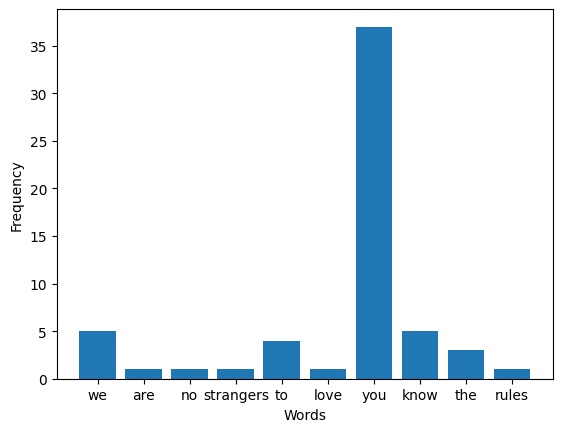

In [9]:
plt.bar(list(fdist.keys())[0:10],list(fdist.values())[0:10])
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

**Unigram model**

In [10]:
#total count of each word
C=sum(fdist.values())
C

385

In [11]:
fdist['strangers']/C

0.0025974025974025974

In [13]:
vocabulary=set(tokens)
vocabulary

{'a',
 'aching',
 'and',
 'any',
 'are',
 'around',
 'ask',
 'been',
 'blind',
 'both',
 'but',
 'commitments',
 'cry',
 'desert',
 'do',
 'dont',
 'down',
 'each',
 'feeling',
 'for',
 'from',
 'full',
 'game',
 'get',
 'give',
 'going',
 'gon',
 'goodbye',
 'got',
 'guy',
 'hearts',
 'how',
 'hurt',
 'i',
 'if',
 'im',
 'inside',
 'it',
 'just',
 'know',
 'known',
 'let',
 'lie',
 'long',
 'love',
 'make',
 'me',
 'na',
 'never',
 'no',
 'of',
 'on',
 'other',
 'play',
 'rules',
 'run',
 'say',
 'see',
 'shy',
 'so',
 'strangers',
 'ta',
 'tell',
 'the',
 'thinking',
 'this',
 'to',
 'too',
 'understand',
 'up',
 'wan',
 'we',
 'were',
 'weve',
 'what',
 'whats',
 'wouldnt',
 'you',
 'your',
 'youre'}

**Bigram model**

In [14]:
bigrams = nltk.bigrams(tokens)
bigrams

<generator object bigrams at 0x79328febb140>

In [16]:
my_bigrams=list(nltk.bigrams(tokens))

In [17]:
my_bigrams[0:10]

[('we', 'are'),
 ('are', 'no'),
 ('no', 'strangers'),
 ('strangers', 'to'),
 ('to', 'love'),
 ('love', 'you'),
 ('you', 'know'),
 ('know', 'the'),
 ('the', 'rules'),
 ('rules', 'and')]

In [20]:
freq_bigrams  = nltk.FreqDist(nltk.bigrams(tokens))
freq_bigrams

FreqDist({('gon', 'na'): 38, ('never', 'gon'): 36, ('you', 'never'): 9, ('na', 'tell'): 8, ('make', 'you'): 8, ('na', 'give'): 6, ('give', 'you'): 6, ('you', 'up'): 6, ('up', 'never'): 6, ('na', 'let'): 6, ...})

In [19]:
freq_bigrams  = nltk.FreqDist(nltk.bigrams(tokens))
freq_bigrams

FreqDist({('gon', 'na'): 38, ('never', 'gon'): 36, ('you', 'never'): 9, ('na', 'tell'): 8, ('make', 'you'): 8, ('na', 'give'): 6, ('give', 'you'): 6, ('you', 'up'): 6, ('up', 'never'): 6, ('na', 'let'): 6, ...})

In [21]:
for my_bigram in  my_bigrams[0:10]:
    print(my_bigram)
    print(freq_bigrams[my_bigram])

('we', 'are')
1
('are', 'no')
1
('no', 'strangers')
1
('strangers', 'to')
1
('to', 'love')
1
('love', 'you')
1
('you', 'know')
1
('know', 'the')
3
('the', 'rules')
1
('rules', 'and')
1


In [24]:
word="strangers"
vocab_probabilities={}
for next_word in vocabulary:
    vocab_probabilities[next_word]=freq_bigrams[(word,next_word)]/fdist[word]

vocab_probabilities=sorted(vocab_probabilities.items(), key=lambda x:x[1],reverse=True)

In [25]:
vocab_probabilities[0:4]

[('to', 1.0), ('what', 0.0), ('a', 0.0), ('are', 0.0)]

**Create a function to calculate the conditional probability of bigram, sort the results, and output them as a list.**

In [ ]:

def make_predictions(my_words, freq_grams, normlize=1, vocabulary=vocabulary):
    """
    Generate predictions for the conditional probability of the next word given a sequence.

    Args:
        my_words (list): A list of words in the input sequence.
        freq_grams (dict): A dictionary containing frequency of n-grams.
        normlize (int): A normalization factor for calculating probabilities.
        vocabulary (list): A list of words in the vocabulary.

    Returns:
        list: A list of predicted words along with their probabilities, sorted in descending order.
    """

    vocab_probabilities = {}  # Initialize a dictionary to store predicted word probabilities

    context_size = len(list(freq_grams.keys())[0])  # Determine the context size from n-grams keys

    # Preprocess input words and take only the relevant context words
    my_tokens = preprocess(my_words)[0:context_size - 1]

    # Calculate probabilities for each word in the vocabulary given the context
    for next_word in vocabulary:
        temp = my_tokens.copy()
        temp.append(next_word)  # Add the next word to the context

        # Calculate the conditional probability using the frequency information
        if normlize!=0:
            vocab_probabilities[next_word] = freq_grams[tuple(temp)] / normlize
        else:
            vocab_probabilities[next_word] = freq_grams[tuple(temp)]
    # Sort the predicted words based on their probabilities in descending order
    vocab_probabilities = sorted(vocab_probabilities.items(), key=lambda x: x[1], reverse=True)

    return vocab_probabilities  # Return the sorted list of predicted words and their probabilities

In [ ]:
my_words="are"

vocab_probabilities=make_predictions(my_words,freq_bigrams,normlize=fdist['are'])

In [ ]:
vocab_probabilities[0:10]

[('no', 1.0),
 ('it', 0.0),
 ('the', 0.0),
 ('wan', 0.0),
 ('im', 0.0),
 ('were', 0.0),
 ('ask', 0.0),
 ('your', 0.0),
 ('this', 0.0),
 ('around', 0.0)]

In [ ]:
vocab_probabilities[0][0]

'no'

In [ ]:
my_song=""
for w in tokens[0:100]:
  my_word=make_predictions(w,freq_bigrams)[0][0]
  my_song+=" "+my_word

In [ ]:
 my_song

' know no strangers to say you never the game and desert long i just lie commitments what im feeling of you never get this from any other for i just wan na tell a never im feeling got ta make you never never gon na tell you never never gon na tell you never never gon na tell around and desert you never gon na tell you never never gon na tell goodbye never gon na tell a lie and desert you never known each other for so long your hearts been aching but youre too shy to say goodbye'

In [ ]:
my_song="i"

for i in range(100):
    my_word=make_predictions(my_word,freq_bigrams)[0][0]
    my_song+=" "+my_word

In [ ]:
 my_song

'i never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never gon na tell a lie and desert you never'

**Trigram modela**

In [ ]:
freq_trigrams  = nltk.FreqDist(nltk.trigrams(tokens))
freq_trigrams

FreqDist({('never', 'gon', 'na'): 36, ('you', 'never', 'gon'): 9, ('gon', 'na', 'give'): 6, ('na', 'give', 'you'): 6, ('give', 'you', 'up'): 6, ('you', 'up', 'never'): 6, ('up', 'never', 'gon'): 6, ('gon', 'na', 'let'): 6, ('na', 'let', 'you'): 6, ('let', 'you', 'down'): 6, ...})

In [ ]:
make_predictions("so do",freq_trigrams,normlize=freq_bigrams[('do','i')] )[0:10]

[('i', 1.0),
 ('it', 0.0),
 ('the', 0.0),
 ('wan', 0.0),
 ('im', 0.0),
 ('were', 0.0),
 ('ask', 0.0),
 ('your', 0.0),
 ('this', 0.0),
 ('around', 0.0)]

In [ ]:
my_song=""

w1=tokens[0]
for w2 in tokens[0:100]:
    gram=w1+' '+w2
    my_word=make_predictions(gram,freq_trigrams )[0][0]
    my_song+=" "+my_word
    w1=w2

In [ ]:
my_song

' it no strangers to love you know the game and so do i a full commitments what im thinking of you wouldnt get this from any other guy i just wan na tell a how im feeling got ta make you cry never gon na say you up never gon na say you down never gon na say around and desert you never gon na say you cry never gon na say goodbye never gon na say a lie and hurt you never known each other for so long your hearts been aching but youre too shy to say it'